### **ReLU activation function**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    """Standard ReLU: f(x) = max(0, x)"""
    return np.maximum(0, x)

def relu_grad(x):
    """Derivative of ReLU: 1 if x>0 else 0"""
    return (x > 0).astype(float)

# quick test
test_vals = np.array([-2, -1, 0, 1, 2])
print("Input:      ", test_vals)
print("ReLU output:", relu(test_vals))
print("ReLU grad:  ", relu_grad(test_vals))

Input:       [-2 -1  0  1  2]
ReLU output: [0 0 0 1 2]
ReLU grad:   [0. 0. 0. 1. 1.]


### **EReLU activation function**

In [ ]:
def erelu(x, training=True, alpha=0.2, k_out=None):
    """
    EReLU (Elastic ReLU):
      f(x) = k*x  for x > 0
      f(x) = 0    for x <= 0
    where k ~ Uniform(1-alpha, 1+alpha) during TRAINING
    (adds stochastic "elasticity" to the positive part as a
    regularizer), and k = 1 during TESTING (deterministic,
    behaves exactly like ReLU at inference time).
    """
    if training:
        k = np.random.uniform(1 - alpha, 1 + alpha, size=np.shape(x))
    else:
        k = np.ones_like(x, dtype=float)
    if k_out is not None:
        k_out.append(k)
    return np.where(x > 0, k * x, 0)

def erelu_grad(x, k):
    """Derivative of EReLU w.r.t. x, given the k used in the forward pass"""
    return np.where(x > 0, k, 0)

# quick test
np.random.seed(42)
test_vals = np.array([-2, -1, 0, 1, 2], dtype=float)

print("Input:                     ", test_vals)
print("EReLU output (training):  ", erelu(test_vals, training=True, alpha=0.2))
print("EReLU output (training):  ", erelu(test_vals, training=True, alpha=0.2))
print("EReLU output (test mode): ", erelu(test_vals, training=False))

Input:                      [-2. -1.  0.  1.  2.]
EReLU output (training):   [0.         0.         0.         1.03946339 1.72481491]
EReLU output (training):   [0.         0.         0.         1.040446   2.16645806]
EReLU output (test mode):  [0. 0. 0. 1. 2.]


### **Visualize both activation functions**

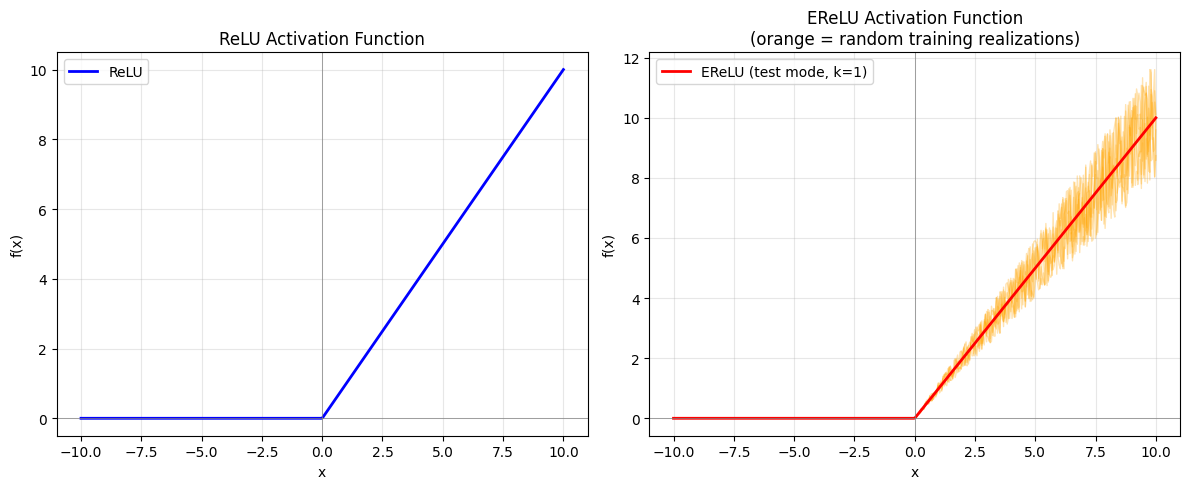

In [ ]:
x = np.linspace(-10, 10, 400)

plt.figure(figsize=(12, 5))

# --- Plot 1: ReLU ---
plt.subplot(1, 2, 1)
plt.plot(x, relu(x), color='blue', linewidth=2, label='ReLU')
plt.title('ReLU Activation Function')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.grid(alpha=0.3)
plt.legend()

# --- Plot 2: EReLU ---
plt.subplot(1, 2, 2)
np.random.seed(0)
for i in range(6):
    y_train = erelu(x, training=True, alpha=0.2)
    plt.plot(x, y_train, color='orange', alpha=0.3, linewidth=1)
y_test = erelu(x, training=False)
plt.plot(x, y_test, color='red', linewidth=2, label='EReLU (test mode, k=1)')
plt.title('EReLU Activation Function\n(orange = random training realizations)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig('step1_activations.png', dpi=150)
plt.show()

### Working Principle

### ReLU (Rectified Linear Unit): f(x) = max(0, x). It passes positive inputs unchanged and clips all negative inputs to zero. It introduces non-linearity while remaining piecewise-linear and cheap to compute, which is why it became the default activation for hidden layers in deep networks.
### EReLU (Elastic ReLU): f(x) = k·x for x > 0, f(x) = 0 for x ≤ 0, where k ~ U(1−α, 1+α) is resampled randomly for every forward pass during training only; at test/inference time k = 1, so EReLU becomes numerically identical to ReLU. The random multiplicative "elasticity" on the positive branch acts like a lightweight, activation-level regularizer (conceptually similar in spirit to Dropout or RReLU, but multiplying rather than dropping units), which perturbs neuron output magnitudes and discourages the network from co-adapting to exact activation values.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Iris dataset
iris = load_iris()
X = iris.data          # shape (150, 4) -> sepal/petal length & width
y = iris.target        # shape (150,)   -> 0, 1, 2 (three species)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", iris.target_names)
print("First 5 rows of X:\n", X[:5])
print("First 5 labels:", y[:5])

# Train/test split (we'll vary test_size and random_state later in Step 5)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features (important for NN training stability)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# One-hot encode labels for our custom NN (3 classes)
def one_hot(y, num_classes=3):
    out = np.zeros((y.shape[0], num_classes))
    out[np.arange(y.shape[0]), y] = 1
    return out

y_train_oh = one_hot(y_train)
y_test_oh = one_hot(y_test)

print("\nTrain shape:", X_train.shape, y_train_oh.shape)
print("Test shape: ", X_test.shape, y_test_oh.shape)

Feature shape: (150, 4)
Target shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']
First 5 rows of X:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
First 5 labels: [0 0 0 0 0]

Train shape: (120, 4) (120, 3)
Test shape:  (30, 4) (30, 3)


In [ ]:
class SimpleNN:
    def __init__(self, input_size=4, hidden_size=8, output_size=3,
                 activation='relu', alpha=0.2, seed=42):
        """
        activation: 'relu' or 'erelu'
        alpha     : EReLU randomness spread (ignored if activation='relu')
        """
        rng = np.random.RandomState(seed)
        # He-style initialization (good for ReLU-family activations)
        self.W1 = rng.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = rng.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))

        self.activation = activation
        self.alpha = alpha

    def _activate(self, z, training):
        if self.activation == 'relu':
            self._k = None
            return relu(z)
        else:  # erelu
            k_store = []
            out = erelu(z, training=training, alpha=self.alpha, k_out=k_store)
            self._k = k_store[0]
            return out

    def _activate_grad(self, z):
        if self.activation == 'relu':
            return relu_grad(z)
        else:
            return erelu_grad(z, self._k)

    @staticmethod
    def _softmax(z):
        z = z - np.max(z, axis=1, keepdims=True)  # numerical stability
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def forward(self, X, training=True):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self._activate(self.z1, training=training)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self._softmax(self.z2)
        return self.a2

    @staticmethod
    def _cross_entropy(y_pred, y_true, eps=1e-9):
        return -np.mean(np.sum(y_true * np.log(y_pred + eps), axis=1))

    def backward(self, X, y_true, y_pred, lr):
        m = X.shape[0]

        # Output layer gradient (softmax + cross-entropy combined)
        dz2 = (y_pred - y_true) / m
        dW2 = self.a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        # Hidden layer gradient
        da1 = dz2 @ self.W2.T
        dz1 = da1 * self._activate_grad(self.z1)
        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # Gradient descent update
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

    def train_step(self, X, y_true, lr):
        y_pred = self.forward(X, training=True)
        loss = self._cross_entropy(y_pred, y_true)
        self.backward(X, y_true, y_pred, lr)
        return loss

    def evaluate(self, X, y_true_oh):
        y_pred = self.forward(X, training=False)
        loss = self._cross_entropy(y_pred, y_true_oh)
        acc = np.mean(np.argmax(y_pred, axis=1) == np.argmax(y_true_oh, axis=1))
        return loss, acc


# quick sanity check: one forward+backward step with each activation
for act in ['relu', 'erelu']:
    nn = SimpleNN(activation=act, seed=42)
    loss = nn.train_step(X_train, y_train_oh, lr=0.1)
    test_loss, test_acc = nn.evaluate(X_test, y_test_oh)
    print(f"[{act}] loss after 1 step: {loss:.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")

[relu] loss after 1 step: 1.5358 | test_loss: 1.3682 | test_acc: 0.1000
[erelu] loss after 1 step: 1.5359 | test_loss: 1.3673 | test_acc: 0.1000


In [ ]:
def train_network(activation, X_train, y_train_oh, X_test, y_test_oh,
                   hidden_size=8, lr=0.1, epochs=200, alpha=0.2, seed=42):
    """
    Trains a SimpleNN with the given activation for `epochs` epochs
    (full-batch gradient descent), tracking train/val loss & accuracy
    at every epoch.
    """
    nn = SimpleNN(input_size=X_train.shape[1], hidden_size=hidden_size,
                  output_size=y_train_oh.shape[1], activation=activation,
                  alpha=alpha, seed=seed)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        # --- training step (uses training=True internally -> random k for erelu) ---
        y_pred_train = nn.forward(X_train, training=True)
        train_loss = nn._cross_entropy(y_pred_train, y_train_oh)
        nn.backward(X_train, y_train_oh, y_pred_train, lr)

        # --- evaluate on train/val in deterministic (test) mode ---
        train_loss_eval, train_acc = nn.evaluate(X_train, y_train_oh)
        val_loss, val_acc = nn.evaluate(X_test, y_test_oh)

        history['train_loss'].append(train_loss_eval)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

    return nn, history


# Train both models with identical architecture & hyperparameters
EPOCHS = 200
LR = 0.1
HIDDEN = 8
SEED = 42

np.random.seed(SEED)  # controls EReLU's random k sampling reproducibility
nn_relu, hist_relu = train_network('relu', X_train, y_train_oh, X_test, y_test_oh,
                                    hidden_size=HIDDEN, lr=LR, epochs=EPOCHS, seed=SEED)

np.random.seed(SEED)
nn_erelu, hist_erelu = train_network('erelu', X_train, y_train_oh, X_test, y_test_oh,
                                      hidden_size=HIDDEN, lr=LR, epochs=EPOCHS, alpha=0.2, seed=SEED)

print("=== ReLU final metrics ===")
print(f"Train loss: {hist_relu['train_loss'][-1]:.4f} | Val loss: {hist_relu['val_loss'][-1]:.4f}")
print(f"Train acc:  {hist_relu['train_acc'][-1]:.4f} | Val acc:  {hist_relu['val_acc'][-1]:.4f}")

print("\n=== EReLU final metrics ===")
print(f"Train loss: {hist_erelu['train_loss'][-1]:.4f} | Val loss: {hist_erelu['val_loss'][-1]:.4f}")
print(f"Train acc:  {hist_erelu['train_acc'][-1]:.4f} | Val acc:  {hist_erelu['val_acc'][-1]:.4f}")

=== ReLU final metrics ===
Train loss: 0.1491 | Val loss: 0.2144
Train acc:  0.9583 | Val acc:  0.9000

=== EReLU final metrics ===
Train loss: 0.1507 | Val loss: 0.2166
Train acc:  0.9667 | Val acc:  0.9000


### **Plot loss & accuracy curves vs epochs**

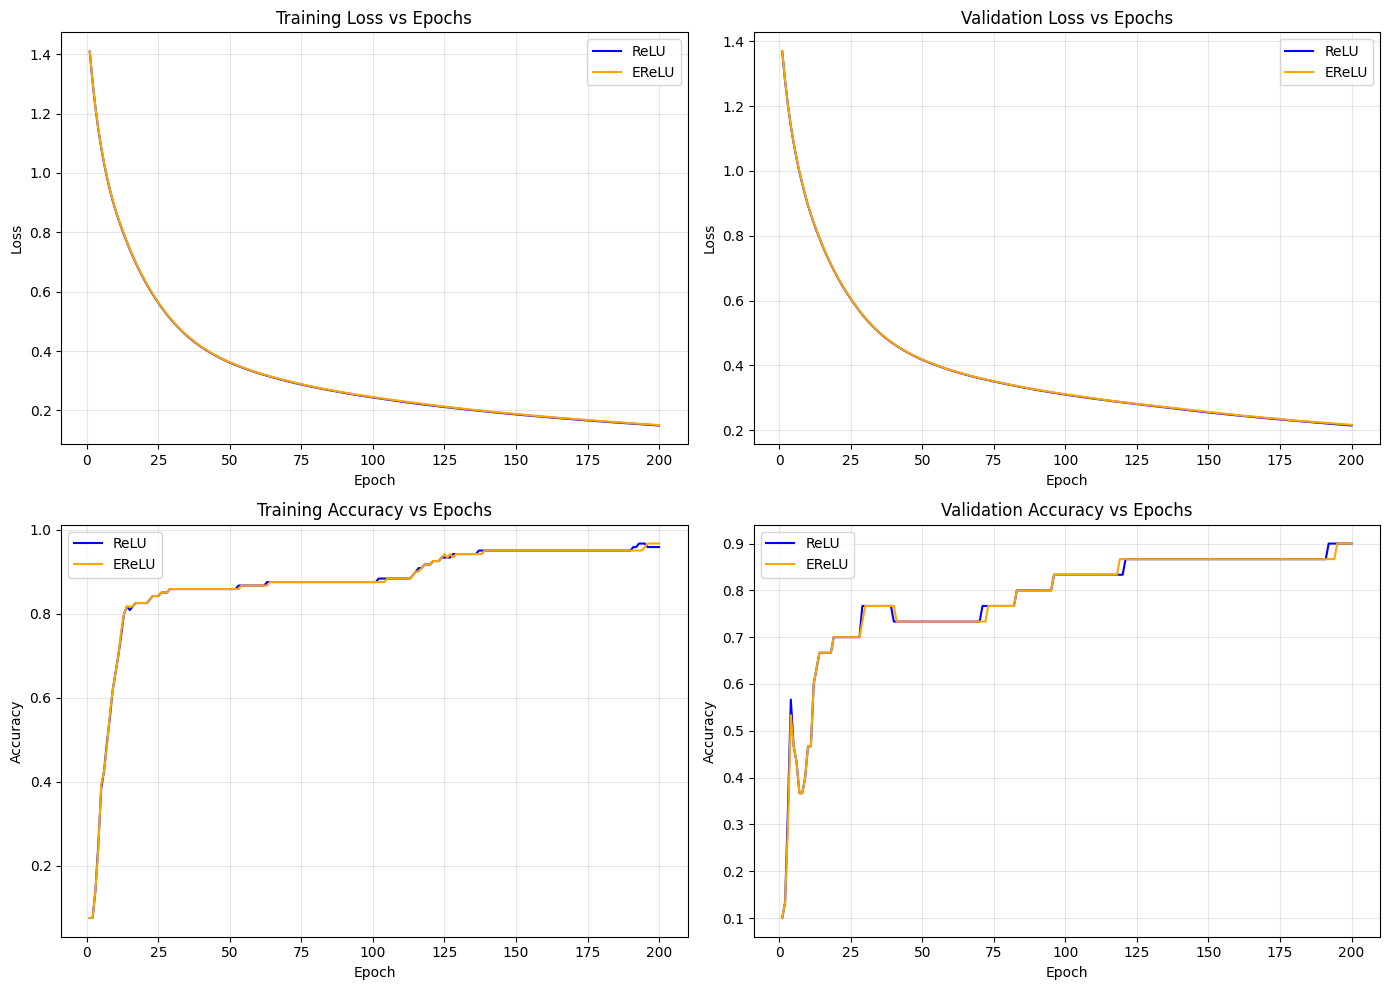

In [ ]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Training Loss ---
axes[0, 0].plot(epochs_range, hist_relu['train_loss'], label='ReLU', color='blue')
axes[0, 0].plot(epochs_range, hist_erelu['train_loss'], label='EReLU', color='orange')
axes[0, 0].set_title('Training Loss vs Epochs')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# --- Validation Loss ---
axes[0, 1].plot(epochs_range, hist_relu['val_loss'], label='ReLU', color='blue')
axes[0, 1].plot(epochs_range, hist_erelu['val_loss'], label='EReLU', color='orange')
axes[0, 1].set_title('Validation Loss vs Epochs')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# --- Training Accuracy ---
axes[1, 0].plot(epochs_range, hist_relu['train_acc'], label='ReLU', color='blue')
axes[1, 0].plot(epochs_range, hist_erelu['train_acc'], label='EReLU', color='orange')
axes[1, 0].set_title('Training Accuracy vs Epochs')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# --- Validation Accuracy ---
axes[1, 1].plot(epochs_range, hist_relu['val_acc'], label='ReLU', color='blue')
axes[1, 1].plot(epochs_range, hist_erelu['val_acc'], label='EReLU', color='orange')
axes[1, 1].set_title('Validation Accuracy vs Epochs')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('step6_training_curves.png', dpi=150)
plt.show()

### Parameter Analysis

In [ ]:
import pandas as pd

def run_experiment(test_size, random_state, lr, epochs, hidden=8, alpha=0.2):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)
    y_tr_oh = one_hot(y_tr)
    y_te_oh = one_hot(y_te)

    results = {}
    for act in ['relu', 'erelu']:
        np.random.seed(random_state)
        _, hist = train_network(act, X_tr, y_tr_oh, X_te, y_te_oh,
                                 hidden_size=hidden, lr=lr, epochs=epochs,
                                 alpha=alpha, seed=random_state)
        results[act] = {
            'train_loss': hist['train_loss'][-1],
            'val_loss': hist['val_loss'][-1],
            'train_acc': hist['train_acc'][-1],
            'val_acc': hist['val_acc'][-1]
        }
    return results


rows = []

# --- Vary test_size ---
for ts in [0.1, 0.2, 0.3, 0.4]:
    res = run_experiment(test_size=ts, random_state=42, lr=0.1, epochs=200)
    for act in ['relu', 'erelu']:
        rows.append({'varied_param': 'test_size', 'value': ts, 'activation': act, **res[act]})

# --- Vary random_state ---
for rs in [0, 1, 42, 123]:
    res = run_experiment(test_size=0.2, random_state=rs, lr=0.1, epochs=200)
    for act in ['relu', 'erelu']:
        rows.append({'varied_param': 'random_state', 'value': rs, 'activation': act, **res[act]})

# --- Vary learning rate ---
for lr in [0.01, 0.05, 0.1, 0.5]:
    res = run_experiment(test_size=0.2, random_state=42, lr=lr, epochs=200)
    for act in ['relu', 'erelu']:
        rows.append({'varied_param': 'learning_rate', 'value': lr, 'activation': act, **res[act]})

# --- Vary epochs ---
for ep in [50, 100, 200, 400]:
    res = run_experiment(test_size=0.2, random_state=42, lr=0.1, epochs=ep)
    for act in ['relu', 'erelu']:
        rows.append({'varied_param': 'epochs', 'value': ep, 'activation': act, **res[act]})

df_results = pd.DataFrame(rows)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print(df_results.to_string(index=False))

df_results.to_csv('step7_parameter_analysis.csv', index=False)

 varied_param    value activation  train_loss  val_loss  train_acc  val_acc
    test_size   0.1000       relu      0.1464    0.2928     0.9407   0.8667
    test_size   0.1000      erelu      0.1479    0.2934     0.9407   0.8667
    test_size   0.2000       relu      0.1491    0.2144     0.9583   0.9000
    test_size   0.2000      erelu      0.1507    0.2166     0.9667   0.9000
    test_size   0.3000       relu      0.1420    0.2431     0.9619   0.8667
    test_size   0.3000      erelu      0.1437    0.2452     0.9619   0.8667
    test_size   0.4000       relu      0.1448    0.2088     0.9667   0.9000
    test_size   0.4000      erelu      0.1460    0.2101     0.9667   0.9000
 random_state   0.0000       relu      0.1175    0.1036     0.9583   0.9667
 random_state   0.0000      erelu      0.1207    0.1065     0.9583   0.9667
 random_state   1.0000       relu      0.1901    0.3206     0.9417   0.9000
 random_state   1.0000      erelu      0.1933    0.3233     0.9417   0.9000
 random_stat

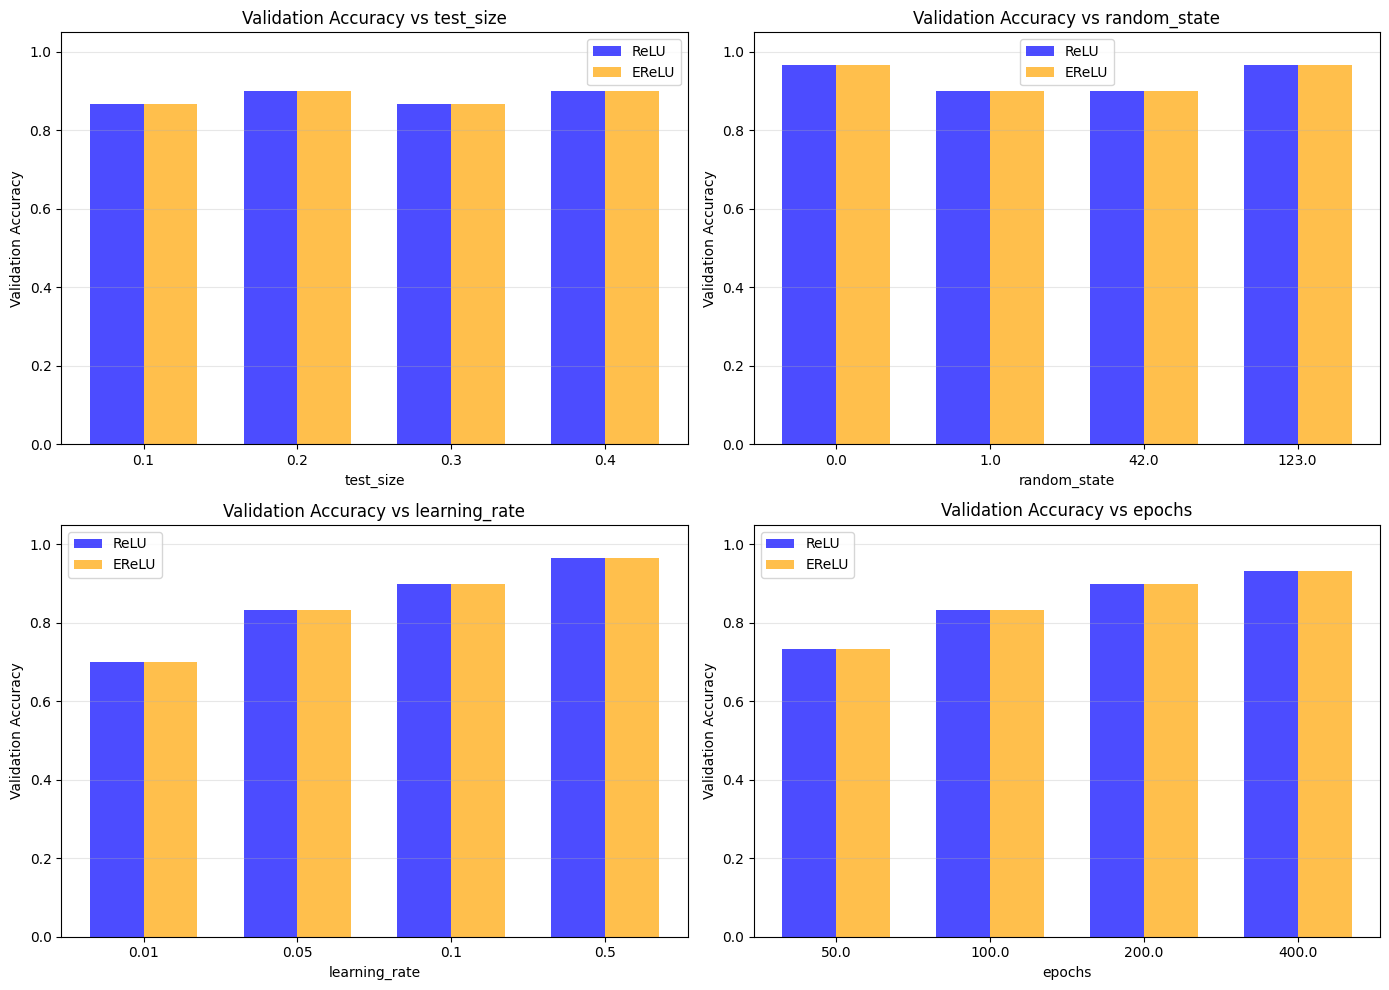

activation              erelu   relu  diff (erelu - relu)
varied_param  value                                      
epochs        50.0000  0.7333 0.7333               0.0000
              100.0000 0.8333 0.8333               0.0000
              200.0000 0.9000 0.9000               0.0000
              400.0000 0.9333 0.9333               0.0000
learning_rate 0.0100   0.7000 0.7000               0.0000
              0.0500   0.8333 0.8333               0.0000
              0.1000   0.9000 0.9000               0.0000
              0.5000   0.9667 0.9667               0.0000
random_state  0.0000   0.9667 0.9667               0.0000
              1.0000   0.9000 0.9000               0.0000
              42.0000  0.9000 0.9000               0.0000
              123.0000 0.9667 0.9667               0.0000
test_size     0.1000   0.8667 0.8667               0.0000
              0.2000   0.9000 0.9000               0.0000
              0.3000   0.8667 0.8667               0.0000
              

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
params = ['test_size', 'random_state', 'learning_rate', 'epochs']
metric = 'val_acc'  # change to 'val_loss', 'train_acc', 'train_loss' to explore others

for ax, param in zip(axes.flat, params):
    sub = df_results[df_results['varied_param'] == param]
    values = sorted(sub['value'].unique())
    relu_vals = [sub[(sub['value'] == v) & (sub['activation'] == 'relu')][metric].values[0] for v in values]
    erelu_vals = [sub[(sub['value'] == v) & (sub['activation'] == 'erelu')][metric].values[0] for v in values]

    x_pos = np.arange(len(values))
    width = 0.35
    ax.bar(x_pos - width/2, relu_vals, width, label='ReLU', color='blue', alpha=0.7)
    ax.bar(x_pos + width/2, erelu_vals, width, label='EReLU', color='orange', alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(v) for v in values])
    ax.set_title(f'Validation Accuracy vs {param}')
    ax.set_xlabel(param)
    ax.set_ylabel('Validation Accuracy')
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('step8_parameter_sweep.png', dpi=150)
plt.show()

# Also print a compact summary: how often did EReLU beat, tie, or lose to ReLU on val_acc?
comparison = df_results.pivot_table(index=['varied_param', 'value'], columns='activation', values='val_acc')
comparison['diff (erelu - relu)'] = comparison['erelu'] - comparison['relu']
print(comparison)
print("\nEReLU better:", (comparison['diff (erelu - relu)'] > 0).sum())
print("Tied:        ", (comparison['diff (erelu - relu)'] == 0).sum())
print("ReLU better: ", (comparison['diff (erelu - relu)'] < 0).sum())

### **For this specific task — a small, shallow network on a small, easily-separable dataset — ReLU and EReLU are practically equivalent in final performance, with ReLU having a marginal edge in raw loss (lower loss, simpler/deterministic computation, no need to sample random numbers every forward pass) and EReLU offering no measurable benefit here. EReLU's regularization effect is more likely to show value on larger, deeper networks trained on more complex, higher-dimensional datasets prone to overfitting — where a network has enough capacity and enough epochs for stochastic activation noise to meaningfully discourage co-adaptation of neurons and reduce the train/validation gap. On Iris, the dataset is too small and the network too simple for that effect to manifest, so ReLU is the more practical choice here on efficiency grounds (deterministic, marginally lower loss, no per-call random sampling overhead), while EReLU remains a viable, low-risk regularization alternative that does not hurt performance.**